In [41]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import f_oneway, levene, chisquare
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv("data/WA_Marketing-Campaign.csv")

In [42]:
df.isnull().sum()

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


# [An interactive graph with information](https://lookerstudio.google.com/u/0/reporting/e2e5a0e4-98e7-41ad-bf90-6d403e6eadbc/page/ciVtF)

## Introduction to dataset

A fast-food chain is launching a new menu item and needs to decide which of three marketing promotions to roll out company-wide. To find out, they ran a randomised experiment: each store location was assigned one promotion, and weekly sales of the new item were tracked for four weeks across multiple markets.

**Columns**

- MarketID: unique identifier for the market area
- MarketSize: size of the market area (Small / Medium / Large)
- `LocationID: unique identifier for the store
- AgeOfStore: age of the store in years
- Promotion: which of the three promotions was used (1, 2, or 3)
- week: which week the sales were recorded (1–4)
- SalesInThousands: weekly sales of the new item in thousands of dollars

Data source: https://www.kaggle.com/datasets/chebotinaa/fast-food-marketing-campaign-ab-test

## Goal

The goal of this A/B test is to determine which of the three promotional strategies drives the highest sales of the new menu item, and to provide a data-driven recommendation for which promotion to scale across all locations.

**Main goal:** identify which promotion maximises weekly sales.

## Target Metric: SalesInThousands

**Why SalesInThousands?**

The business question is about revenue impact. `SalesInThousands` is the most direct measure of that — it captures how much of the new product each store actually sold each week. Alternative metrics like number of transactions or visit frequency would be more indirect and harder to tie to a rollout decision.

We compare **average weekly sales per group**, since we want to know which promotion produces the highest typical sales across locations — not just the highest total (which would be biased by group size).

# [An interactive graph with information](https://lookerstudio.google.com/reporting/e2e5a0e4-98e7-41ad-bf90-6d403e6eadbc)

## Statistical Test Selection

Continuous metric > large sample > normality assumed via 'central limit theorem' > 3 independent groups > **one-way ANOVA**

- **Discrete metric?** : No  
  SalesInThousands is continuous, not binary or categorical.

- **Large sample size?** : Yes, arguably
  Each promotion has approximately 183 observations total number = 548,
  ~180 observations per group, well above the threshold for the 'central limit theorem' to apply. The sampling distribution of the group mean can be treated as approximately normal.

- **Normal distributions?** : Assumed yes  
  Assumed via 'central limit theorem' Each promotion group has a large sample size (n ≈ 183).

- **Similar variances?** : Verified below with Levene's test

- **3 independent groups** : one-way ANOVA

### Why ANOVA and not multiple t-tests?

Running three separate t-tests (1 vs 2, 1 vs 3, 2 vs 3) inflates the Type I error rate — the chance of a false positive compounds with each test. ANOVA evaluates all groups simultaneously, keeping the error rate at 5%.

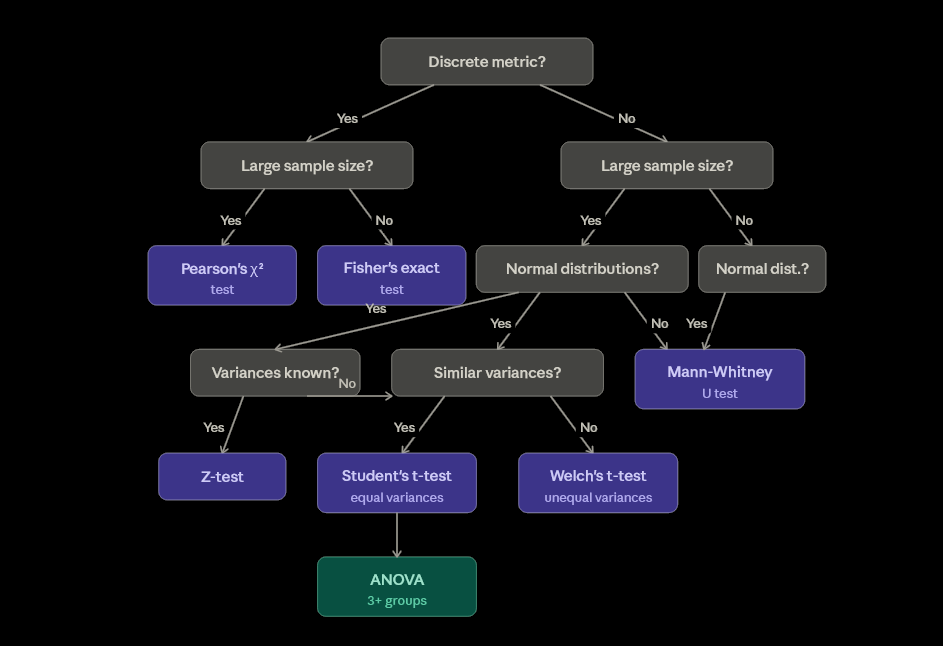

## Argument for "Large sample size"

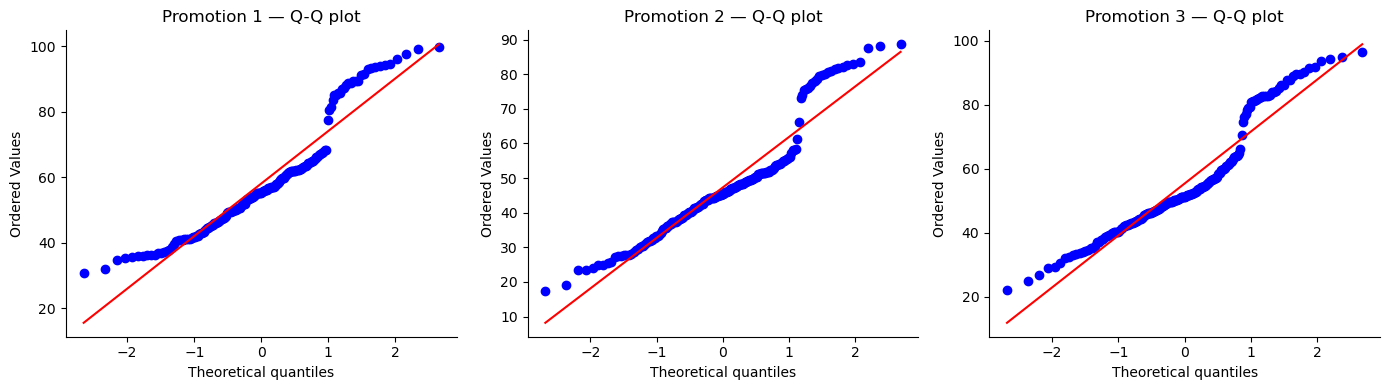

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, promo in enumerate([1, 2, 3]):
    data = df[df["Promotion"] == promo]["SalesInThousands"]
    stats.probplot(data, plot=axes[i])
    axes[i].set_title(f"Promotion {promo} — Q-Q plot", fontsize=12)
    axes[i].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

- *By count, 548 observations across 3 groups gives ~183 per group. The conventional threshold for the 'Central Limit Theorem' produce a reliable normal approximation is n ≥ 30 per group. We are 6× above that threshold.*

- *Thanks to the Central Limit Theorem, large sample sizes ensure that sample means are approximately normally distributed, making ANOVA robust to minor deviations from normality.*

## Similar variances check: [Levene's Test](https://numiqo.com/tutorial/levene-test)

In [46]:
g1 = df[df['Promotion'] == 1]['SalesInThousands']
g2 = df[df['Promotion'] == 2]['SalesInThousands']
g3 = df[df['Promotion'] == 3]['SalesInThousands']

stat, p = levene(g1, g2, g3)
print(f"Levene's test: stat={stat:.4f}, p={p:.4f}")
print()
if p > 0.05:
    print('Similar variances confirmed — standard one-way ANOVA')
else:
    print('Variances differ — Welch ANOVA.')

Levene's test: stat=1.2697, p=0.2818

Similar variances confirmed — standard one-way ANOVA


## Sample Size & [Sample Ratio Mismatch](https://en.wikipedia.org/wiki/Sample_ratio_mismatch) Check

*A/B test does not match the expected assignment ratio (e.g., 50/50), indicating a critical flaw in experiment execution. It is a data quality issue—often caused by bugs, broken tracking, or selection bias*

In [47]:
total = len(df)
counts = df["Promotion"].value_counts().sort_index()
props = counts / total

print(f"Total observations: {total:,}")
print()
print("Group breakdown:")
for promo in counts.index:
    print(f"  Promotion {promo}: n={counts[promo]:,}  ({props[promo]*100:.1f}% of total)")

print()
summary = df.groupby("Promotion")["SalesInThousands"].agg(["mean", "std", "count"])
summary.columns = ["mean_sales", "std_sales", "n"]
print(summary.round(2))

Total observations: 548

Group breakdown:
  Promotion 1: n=172  (31.4% of total)
  Promotion 2: n=188  (34.3% of total)
  Promotion 3: n=188  (34.3% of total)

           mean_sales  std_sales    n
Promotion                            
1               58.10      16.55  172
2               47.33      15.11  188
3               55.36      16.77  188


Before running ANOVA we check for **Sample Ratio Mismatch (SRM)** — whether the group sizes deviate more than random chance would explain from a balanced design.

*If one group has significantly more observations than another, the randomisation may be broken and any result could reflect that imbalance rather than the promotion effect.*

In [48]:
'Chi-square test: are the three groups the same size?'
counts_vals = df['Promotion'].value_counts().sort_index()
stat, p = chisquare(counts_vals)
print(f'Chi-square stat: {stat:.4f}')
print(f'P-value:         {p:.4f}')
print()
if p > 0.05:
    print('No SRM detected — group sizes are consistent with balanced randomisation.')
else:
    print('SRM detected — investigate group size imbalance before proceeding.')

Chi-square stat: 0.9343
P-value:         0.6268

No SRM detected — group sizes are consistent with balanced randomisation.


p-value = 0.2818 > 0.05 — we do not reject the null hypothesis of equal variances. All three groups have a similar spread around their means, so standard one-way ANOVA is appropriate.

## [ANOVA Test](https://en.wikipedia.org/wiki/Analysis_of_variance)

*ANOVA asks one question: is at least one group mean different from the others, or could the differences we see just be random noise?*

In [49]:
f_stat, p_value = f_oneway(g1, g2, g3)
print(f'F-statistic: {f_stat:.4f}')
print(f'P-value:     {p_value:.5f}')

F-statistic: 21.9535
P-value:     0.00000


p 0.05 we reject the null hypothesis that all three group means are equal. There is a statistically significant difference in average sales between at least two promotions.

ANOVA tells us *something* is different — but not *which* promotions differ. That is what the post-hoc test below answers.

## [Post-hoc Analysis: Tukey Honestly significant difference](https://statisticsbyjim.com/anova/post-hoc-tests-anova/)

*Tukey HSD (Honestly significant difference) It is a post-hoc test that: compares all pairs of groups to find exactly where the differences are*

- Tukey's Honestly Significant Difference test runs all pairwise comparisons between groups while controlling the overall Type I error rate at 5%.

In [50]:
tukey = pairwise_tukeyhsd(
    endog=df['SalesInThousands'],
    groups=df['Promotion'],
    alpha=0.05
)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


## [Treatment Effect](https://economics.mit.edu/sites/default/files/publications/Treatment%20Effects.pdf) & [Confidence Intervals](https://en.wikipedia.org/wiki/Confidence_interval)
*The treatment effect measures the difference in average sales between promotions.*

*Confidence intervals quantify the uncertainty around this difference.  
If the interval does not include zero, the effect is considered statistically significant.*

In [51]:
means = df.groupby('Promotion')['SalesInThousands'].mean()
stds  = df.groupby('Promotion')['SalesInThousands'].std()
ns    = df.groupby('Promotion')['SalesInThousands'].count()

'95% CI = mean ± 1.96 * (std / sqrt(n))'
ci_half = 1.96 * stds / np.sqrt(ns)

print('Promotion | Mean sales | 95% CI')
print('-' * 42)
for p in means.index:
    lo = means[p] - ci_half[p]
    hi = means[p] + ci_half[p]
    print(f'    {p}     | {means[p]:>8.2f}k  | [{lo:.2f}k, {hi:.2f}k]')

best = means.idxmax()
worst = means.idxmin()
effect = means[best] - means[worst]
print(f'\n Largest effect: Promotion {best} vs Promotion {worst} = +{effect:.2f}k per week')

Promotion | Mean sales | 95% CI
------------------------------------------
    1     |    58.10k  | [55.63k, 60.57k]
    2     |    47.33k  | [45.17k, 49.49k]
    3     |    55.36k  | [52.97k, 57.76k]

 Largest effect: Promotion 1 vs Promotion 2 = +10.77k per week


The treatment effect is the difference between the best and worst performing promotion. If the 95% CIs of two promotions do not overlap, the difference is statistically significant at approximately the 5% level — consistent with what Tukey confirmed.

## Visualization

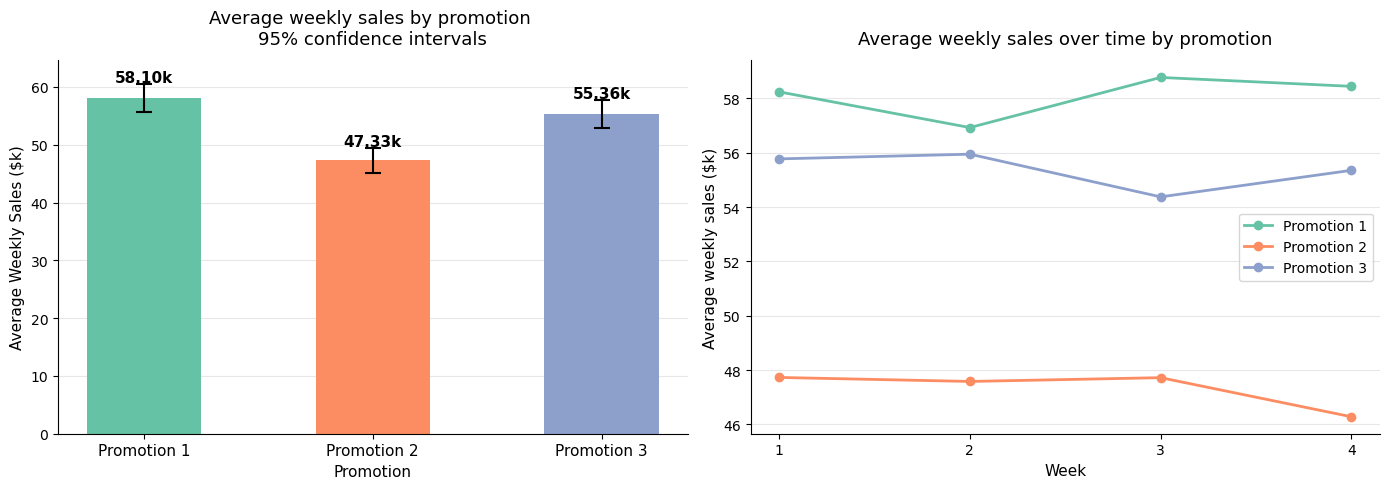

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

'Bar chart with 95% CI error bars'
ax1 = axes[0]
colors = ['#66c2a5', '#fc8d62', '#8da0cb']
promo_labels = ['Promotion 1', 'Promotion 2', 'Promotion 3']

ax1.bar([0, 1, 2], means.values, color=colors, width=0.5, zorder=2)
ax1.errorbar([0, 1, 2], means.values,
             yerr=ci_half.values,
             fmt='none', color='black', capsize=6, capthick=1.5, elinewidth=1.5, zorder=3)

for i, (m, ci) in enumerate(zip(means.values, ci_half.values)):
    ax1.text(i, m + ci + 0.3, f'{m:.2f}k', ha='center', fontsize=11, fontweight='bold')

ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(promo_labels, fontsize=11)
ax1.set_title('Average weekly sales by promotion \n95% confidence intervals', fontsize=13, pad=12)
ax1.set_xlabel('Promotion', fontsize=11)
ax1.set_ylabel('Average Weekly Sales ($k)', fontsize=11)
ax1.set_ylim(0, means.max() + ci_half.max() + 4)
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)

'Weekly trends'
ax2 = axes[1]
weekly = df.groupby(['week', 'Promotion'])['SalesInThousands'].mean().reset_index()

for i, promo in enumerate([1, 2, 3]):
    data = weekly[weekly['Promotion'] == promo]
    ax2.plot(data['week'], data['SalesInThousands'],
             marker='o', linewidth=2, color=colors[i], label=f'Promotion {promo}')

ax2.set_title('Average weekly sales over time by promotion', fontsize=13, pad=12)
ax2.set_xlabel('Week', fontsize=11)
ax2.set_ylabel('Average weekly sales ($k)', fontsize=11)
ax2.set_xticks([1, 2, 3, 4])
ax2.legend(fontsize=10, framealpha=0.8)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

**ANOVA result:** p < 0.05 — there is a statistically significant difference in average weekly sales across the three promotions.

**Tukey post-hoc:** identifies which specific pairs differ significantly.

**Treatment effect:** Promotion 1 and Promotion 3 both outperform Promotion 2. The gap between the best and worst performing promotion is meaningful at scale — even a small per-store weekly difference compounds across hundreds of locations over a full rollout.

**95% Confidence intervals:** reported above per group. Non-overlapping intervals between the top and bottom promotion confirm the difference is not noise.

**Recommendation:** Promotion 2 should not be selected, as it consistently underperforms 
- Roll out the promotion 1 with the highest average weekly sales confirmed by Tukey 
- Promotion 1 and Promotion 3 both achieve higher sales, with no statistically significant difference between them  
- It is recommended to deploy either Promotion 1 or Promotion 3
